# Installing libraries

In [ ]:
!pip install --upgrade transformers
!pip install datasets evaluate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 112.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 100.2 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.20.3
    Uninstalling tokenizers-0.20.3:
      Successfully uninstalled tokenizers-0.20.3
  Attempting uninstall: transformers
    Found existing installation: transformers 4.46.3
    Uninstalling transformers-4.46.3:
      Successfully uninstalled transformers-4.46.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━

In [ ]:
!pip install gensim

In [ ]:
!pip install wordcloud

# Data Preparation and Preprocessing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/ITC508_data/cleaned_dataset.csv')

df.head()

,comment,sentiment_score
0,I have learned many things related to our course,1
1,Experience new class room in centennial building,1
2,"My positive experience on JRU, they are approa...",1
3,The school has been consiedrate to their students,1
4,Spending time with my colleagues learning new ...,1


In [ ]:
df['comment'] = df['comment'].apply(lambda x: str.lower(x))

df.head()

,comment,sentiment_score
0,i have learned many things related to our course,1
1,experience new class room in centennial building,1
2,"my positive experience on jru, they are approa...",1
3,the school has been consiedrate to their students,1
4,spending time with my colleagues learning new ...,1


In [ ]:
import re

def remove_punct(text):
    text = re.sub(r'[^\w\s]', '', text)
    return text

df['comment'] = df['comment'].apply(lambda x: remove_punct(x).strip())

df.head()

,comment,sentiment_score
0,i have learned many things related to our course,1
1,experience new class room in centennial building,1
2,my positive experience on jru they are approac...,1
3,the school has been consiedrate to their students,1
4,spending time with my colleagues learning new ...,1


In [ ]:
import nltk

nltk.download('stopwords')

from nltk.corpus import stopwords

stopwords = set(stopwords.words('english'))

df['comment'] = df['comment'].apply(lambda x: ' '.join([word for word in x.split() if word not in stopwords]))

df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,comment,sentiment_score
0,learned many things related course,1
1,experience new class room centennial building,1
2,positive experience jru approachable question ...,1
3,school consiedrate students,1
4,spending time colleagues learning new things p...,1


In [ ]:
file_path = '/content/drive/My Drive/ITC508_data/transformed-dataset.csv'
df.to_csv(file_path, index=False)

# Splitting Dataset (BERT)

In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

dataset = pd.read_csv('/content/drive/MyDrive/ITC508_data/transformed-dataset.csv')

dataset = dataset.dropna().reset_index(drop=True)

dataset.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,comment,sentiment_score
0,learned many things related course,1
1,experience new class room centennial building,1
2,positive experience jru approachable question ...,1
3,school consiedrate students,1
4,spending time colleagues learning new things p...,1


In [ ]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

train_val_dataset, test_dataset = train_test_split(dataset, test_size=0.1, random_state=42)

train_dataset, val_dataset = train_test_split(train_val_dataset, test_size=0.2, random_state=42)

train_dataset = Dataset.from_pandas(train_dataset)
val_dataset = Dataset.from_pandas(val_dataset)
test_dataset = Dataset.from_pandas(test_dataset)

# 1)	google-bert/bert-base-uncased

In [ ]:
# Tokenizing the dataset

from transformers import BertTokenizer, BertForSequenceClassification

GoogleBertTokenizer = BertTokenizer.from_pretrained('google-bert/bert-base-uncased')

def tokenize_function(examples):
    tokenized = GoogleBertTokenizer(
        examples["comment"],  # Replace with the column name for text data
        truncation=True,
        padding="max_length",
        max_length=128
    )
    tokenized["labels"] = examples["sentiment_score"]  # Replace 'label' with your column for target labels
    return tokenized

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

GoogleBertModel = BertForSequenceClassification.from_pretrained('google-bert/bert-base-uncased', num_labels=2)

Map:   0%|          | 0/649 [00:00<?, ? examples/s]

Map:   0%|          | 0/163 [00:00<?, ? examples/s]

Map:   0%|          | 0/91 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import TrainingArguments, Trainer
import numpy as np
import evaluate, time

accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
    precision = precision_metric.compute(predictions=predictions, references=labels)
    recall = recall_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels)

    return {
        "accuracy": accuracy["accuracy"],
        "precision": precision["precision"],
        "recall": recall["recall"],
        "f1": f1["f1"]
    }

num_of_epochs = 10
batches_per_epoch = len(tokenized_train_dataset)

training_args = TrainingArguments(
    output_dir='./bert-results',
    num_train_epochs=num_of_epochs,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=5e-5,
    weight_decay=0.01,
    warmup_steps=0,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    lr_scheduler_type="linear",
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)

GoogleBertTrainer = Trainer(
    model=GoogleBertModel,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    compute_metrics=compute_metrics
)

start_time = time.time()
GoogleBertTrainer.train()
end_time = time.time()

print(f"Training time: {end_time - start_time} seconds")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.490200,0.245740,0.907975,0.950000,0.926829,0.938272
2,0.225000,0.186925,0.932515,0.959016,0.951220,0.955102
3,0.029700,0.460656,0.907975,0.909091,0.975610,0.941176
4,0.065600,0.343434,0.932515,0.944444,0.967480,0.955823
5,0.014000,0.297603,0.932515,0.966667,0.943089,0.954733
6,0.004700,0.319942,0.938650,0.959350,0.959350,0.959350
7,0.027400,0.316024,0.944785,0.975000,0.951220,0.962963
8,0.068400,0.300430,0.944785,0.967213,0.959350,0.963265
9,0.001200,0.327925,0.938650,0.966942,0.951220,0.959016
10,0.003200,0.321622,0.938650,0.966942,0.951220,0.959016


Training time: 255.51973628997803 seconds


In [ ]:
GoogleBertResults = GoogleBertTrainer.evaluate(eval_dataset=tokenized_test_dataset)

print("Test results: ")

for result in GoogleBertResults:
  print(f"{result}: {GoogleBertResults[result]}")

Test results: 
eval_loss: 0.30952581763267517
eval_accuracy: 0.945054945054945
eval_precision: 0.9846153846153847
eval_recall: 0.9411764705882353
eval_f1: 0.9624060150375939
eval_runtime: 0.7004
eval_samples_per_second: 129.921
eval_steps_per_second: 8.566
epoch: 10.0


In [ ]:
save_path = "/content/drive/My Drive/ITC508_model/google-bert-finetuned-model"
GoogleBertTrainer.save_model(save_path)

save_path = "/content/drive/My Drive/ITC508_model/Tokenizer/google-bert-finetuned-tokenizer"
GoogleBertTokenizer.save_pretrained(save_path)

('/content/drive/My Drive/ITC508_model/Tokenizer/google-bert-finetuned-tokenizer/tokenizer_config.json',
 '/content/drive/My Drive/ITC508_model/Tokenizer/google-bert-finetuned-tokenizer/special_tokens_map.json',
 '/content/drive/My Drive/ITC508_model/Tokenizer/google-bert-finetuned-tokenizer/vocab.txt',
 '/content/drive/My Drive/ITC508_model/Tokenizer/google-bert-finetuned-tokenizer/added_tokens.json')

# 2)	FacebookAI/xlm-roberta-base

In [ ]:
# Tokenizing the dataset

from transformers import XLMRobertaTokenizer, XLMRobertaForSequenceClassification

RobertaTokenizer = XLMRobertaTokenizer.from_pretrained('FacebookAI/xlm-roberta-base')

def tokenize_function(examples):
    tokenized = RobertaTokenizer(
        examples["comment"],  # Replace with the column name for text data
        truncation=True,
        padding="max_length",
        max_length=128
    )
    tokenized["labels"] = examples["sentiment_score"]  # Replace 'label' with your column for target labels
    return tokenized

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

RobertaModel = XLMRobertaForSequenceClassification.from_pretrained('FacebookAI/xlm-roberta-base', num_labels=2)

Map:   0%|          | 0/649 [00:00<?, ? examples/s]

Map:   0%|          | 0/163 [00:00<?, ? examples/s]

Map:   0%|          | 0/91 [00:00<?, ? examples/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import TrainingArguments, Trainer
import numpy as np
import evaluate, time

accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
    precision = precision_metric.compute(predictions=predictions, references=labels)
    recall = recall_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels)

    return {
        "accuracy": accuracy["accuracy"],
        "precision": precision["precision"],
        "recall": recall["recall"],
        "f1": f1["f1"]
    }

num_of_epochs = 10
batches_per_epoch = len(tokenized_train_dataset)

training_args = TrainingArguments(
    output_dir='./roberta-results',
    num_train_epochs=num_of_epochs,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=5e-5,
    weight_decay=0.01,
    warmup_steps=0,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    lr_scheduler_type="linear",
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)

RobertaTrainer = Trainer(
    model=RobertaModel,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    compute_metrics=compute_metrics
)

start_time = time.time()
RobertaTrainer.train()
end_time = time.time()

print(f"Training time: {end_time - start_time} seconds")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.508700,0.398653,0.754601,0.754601,1.000000,0.860140
2,0.438400,0.357785,0.901840,0.896296,0.983740,0.937984
3,0.400700,0.543693,0.852761,0.846154,0.983740,0.909774
4,0.423100,0.423018,0.889571,0.964602,0.886179,0.923729
5,0.177400,0.205075,0.944785,0.945312,0.983740,0.964143
6,0.231200,0.390782,0.901840,0.965217,0.902439,0.932773
7,0.086000,0.402882,0.920245,0.916667,0.983740,0.949020
8,0.192700,0.290513,0.938650,0.952000,0.967480,0.959677
9,0.048100,0.365121,0.920245,0.958333,0.934959,0.946502
10,0.038900,0.367020,0.920245,0.958333,0.934959,0.946502


Training time: 763.7282745838165 seconds


In [ ]:
RobertaResults = RobertaTrainer.evaluate(eval_dataset=tokenized_test_dataset)

print("Test results: ")

for result in RobertaResults:
  print(f"{result}: {RobertaResults[result]}")

Test results: 
eval_loss: 0.1877772957086563
eval_accuracy: 0.9560439560439561
eval_precision: 0.9444444444444444
eval_recall: 1.0
eval_f1: 0.9714285714285714
eval_runtime: 0.6472
eval_samples_per_second: 140.616
eval_steps_per_second: 9.271
epoch: 10.0


In [ ]:
save_path = "/content/drive/My Drive/ITC508_model/xlm-roberta-finetuned-model"
RobertaTrainer.save_model(save_path)

save_path = "/content/drive/My Drive/ITC508_model/Tokenizer/xlm-roberta-finetuned-tokenizer"
RobertaTokenizer.save_pretrained(save_path)

('/content/drive/My Drive/ITC508_model/Tokenizer/xlm-roberta-finetuned-tokenizer/tokenizer_config.json',
 '/content/drive/My Drive/ITC508_model/Tokenizer/xlm-roberta-finetuned-tokenizer/special_tokens_map.json',
 '/content/drive/My Drive/ITC508_model/Tokenizer/xlm-roberta-finetuned-tokenizer/sentencepiece.bpe.model',
 '/content/drive/My Drive/ITC508_model/Tokenizer/xlm-roberta-finetuned-tokenizer/added_tokens.json')

# 3)	microsoft/deberta-v3-base

In [ ]:
# Tokenizing the dataset

from transformers import DebertaV2Tokenizer, DebertaV2ForSequenceClassification

DebertaTokenizer = DebertaV2Tokenizer.from_pretrained('microsoft/deberta-v3-base')

def tokenize_function(examples):
    tokenized = DebertaTokenizer(
        examples["comment"],  # Replace with the column name for text data
        truncation=True,
        padding="max_length",
        max_length=128
    )
    tokenized["labels"] = examples["sentiment_score"]  # Replace 'label' with your column for target labels
    return tokenized

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

DebertaModel = DebertaV2ForSequenceClassification.from_pretrained('microsoft/deberta-v3-base', num_labels=2)

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

Map:   0%|          | 0/649 [00:00<?, ? examples/s]

Map:   0%|          | 0/163 [00:00<?, ? examples/s]

Map:   0%|          | 0/91 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import TrainingArguments, Trainer
import numpy as np
import evaluate, time

accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
    precision = precision_metric.compute(predictions=predictions, references=labels)
    recall = recall_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels)

    return {
        "accuracy": accuracy["accuracy"],
        "precision": precision["precision"],
        "recall": recall["recall"],
        "f1": f1["f1"]
    }

num_of_epochs = 10
batches_per_epoch = len(tokenized_train_dataset)

training_args = TrainingArguments(
    output_dir='./deberta-results',
    num_train_epochs=num_of_epochs,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=5e-5,
    weight_decay=0.01,
    warmup_steps=0,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    lr_scheduler_type="linear",
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)

DebertaTrainer = Trainer(
    model=DebertaModel,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    compute_metrics=compute_metrics
)

start_time = time.time()
DebertaTrainer.train()
end_time = time.time()

print(f"Training time: {end_time - start_time} seconds")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.499400,0.399131,0.754601,0.754601,1.000000,0.860140
2,0.257000,0.259852,0.926380,0.951220,0.951220,0.951220
3,0.237500,0.353954,0.907975,0.915385,0.967480,0.940711
4,0.166200,0.355138,0.907975,0.965517,0.910569,0.937238
5,0.063200,0.314722,0.932515,0.959016,0.951220,0.955102
6,0.008600,0.464314,0.926380,0.966387,0.934959,0.950413
7,0.015200,0.345360,0.932515,0.966667,0.943089,0.954733
8,0.083100,0.375455,0.932515,0.974576,0.934959,0.954357
9,0.003100,0.342255,0.932515,0.966667,0.943089,0.954733
10,0.013000,0.335528,0.932515,0.966667,0.943089,0.954733


Training time: 421.54740595817566 seconds


In [ ]:
DebertaResults = DebertaTrainer.evaluate(eval_dataset=tokenized_test_dataset)

print("Test results: ")

for result in DebertaResults:
  print(f"{result}: {DebertaResults[result]}")

Test results: 
eval_loss: 0.19458380341529846
eval_accuracy: 0.9560439560439561
eval_precision: 0.9705882352941176
eval_recall: 0.9705882352941176
eval_f1: 0.9705882352941176
eval_runtime: 0.9357
eval_samples_per_second: 97.251
eval_steps_per_second: 6.412
epoch: 10.0


In [ ]:
save_path = "/content/drive/My Drive/ITC508_model/deberta-finetuned-model"
DebertaTrainer.save_model(save_path)

save_path = "/content/drive/My Drive/ITC508_model/Tokenizer/deberta-finetuned-tokenizer"
DebertaTokenizer.save_pretrained(save_path)

('/content/drive/My Drive/ITC508_model/Tokenizer/deberta-finetuned-tokenizer/tokenizer_config.json',
 '/content/drive/My Drive/ITC508_model/Tokenizer/deberta-finetuned-tokenizer/special_tokens_map.json',
 '/content/drive/My Drive/ITC508_model/Tokenizer/deberta-finetuned-tokenizer/spm.model',
 '/content/drive/My Drive/ITC508_model/Tokenizer/deberta-finetuned-tokenizer/added_tokens.json')

# Splitting Dataset (LDA)

In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

dataset = pd.read_csv('/content/drive/MyDrive/ITC508_data/transformed-dataset.csv')

dataset = dataset.dropna().reset_index(drop=True)

dataset.head()

Mounted at /content/drive


,comment,sentiment_score
0,learned many things related course,1
1,experience new class room centennial building,1
2,positive experience jru approachable question ...,1
3,school consiedrate students,1
4,spending time colleagues learning new things p...,1


In [ ]:
positive_dataset = dataset[dataset["sentiment_score"] == 1]

positive_dataset[:5]

,comment,sentiment_score
0,learned many things related course,1
1,experience new class room centennial building,1
2,positive experience jru approachable question ...,1
3,school consiedrate students,1
4,spending time colleagues learning new things p...,1


In [ ]:
negative_dataset = dataset[dataset["sentiment_score"] == 0]

negative_dataset[:5]

,comment,sentiment_score
673,lack equipment bsemc students,0
674,guard,0
675,negative experiences takes time process docume...,0
676,permit exam pain students thankfully law prohi...,0
677,organized giving final instructions students,0


# LDA (BoW)

In [ ]:
# BoW Representation (Positive)

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from pprint import pprint

positive_dataset.loc[:, 'tokenized_comment'] = positive_dataset.loc[:, 'comment'].apply(lambda x: x.split())

dictionary = corpora.Dictionary(positive_dataset["tokenized_comment"])

corpus = [dictionary.doc2bow(doc) for doc in positive_dataset["tokenized_comment"]]

for num_topics in range(2, 6):
    positive_bow_lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, passes=10, random_state=42)
    coherence_model = CoherenceModel(model=positive_bow_lda_model, corpus=corpus, dictionary=dictionary, coherence='u_mass')
    print(f"Num Topics: {num_topics}, Coherence Score: {coherence_model.get_coherence()}")

    print(f"Topics for {num_topics} topics:")
    for idx, topic in positive_bow_lda_model.show_topics(num_topics=num_topics, num_words=5, formatted=False):
        topic_words = [word[0] for word in topic]
        print(f"  Topic {idx}: {', '.join(topic_words)}")
    print("\n")

Num Topics: 2, Coherence Score: -8.036790605226692
Topics for 2 topics:
  Topic 0: experience, jru, friends, experiences, university
  Topic 1: good, education, quality, professors, facilities


Num Topics: 3, Coherence Score: -8.129382879682272
Topics for 3 topics:
  Topic 0: experience, jru, experiences, skills, positive
  Topic 1: good, education, quality, friends, professors
  Topic 2: learning, friends, good, professors, facilities


Num Topics: 4, Coherence Score: -9.453867680571612
Topics for 4 topics:
  Topic 0: jru, skills, friends, experience, positive
  Topic 1: good, education, quality, friends, lot
  Topic 2: learning, friends, jru, new, lot
  Topic 3: good, facilities, great, experience, students


Num Topics: 5, Coherence Score: -10.18821214182238
Topics for 5 topics:
  Topic 0: skills, lot, university, positive, experiences
  Topic 1: good, education, quality, friends, lot
  Topic 2: learning, jru, lot, good, professors
  Topic 3: facilities, good, experience, professor

In [ ]:
# BoW Representation (Negative)

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from pprint import pprint

negative_dataset.loc[:, 'tokenized_comment'] = negative_dataset.loc[:, 'comment'].apply(lambda x: x.split())

dictionary = corpora.Dictionary(negative_dataset["tokenized_comment"])

corpus = [dictionary.doc2bow(doc) for doc in negative_dataset["tokenized_comment"]]

for num_topics in range(2, 6):
    negative_bow_lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, passes=10, random_state=42)
    coherence_model = CoherenceModel(model=negative_bow_lda_model, corpus=corpus, dictionary=dictionary, coherence='u_mass')
    print(f"Num Topics: {num_topics}, Coherence Score: {coherence_model.get_coherence()}")

    print(f"Topics for {num_topics} topics:")
    for idx, topic in negative_bow_lda_model.show_topics(num_topics=num_topics, num_words=5, formatted=False):
        topic_words = [word[0] for word in topic]
        print(f"  Topic {idx}: {', '.join(topic_words)}")
    print("\n")

Num Topics: 2, Coherence Score: -17.167224756691866
Topics for 2 topics:
  Topic 0: students, wifi, classes, slow, guards
  Topic 1: professors, jru, negative, students, late


Num Topics: 3, Coherence Score: -17.121951026202044
Topics for 3 topics:
  Topic 0: g, classes, slow, pandemic, aircon
  Topic 1: professors, negative, professor, students, experiences
  Topic 2: students, wifi, connection, professors, jru


Num Topics: 4, Coherence Score: -18.11049537536702
Topics for 4 topics:
  Topic 0: guards, aircon, students, strict, sometimes
  Topic 1: professors, professor, late, negative, jru
  Topic 2: professors, students, jru, slow, connection
  Topic 3: wifi, online, g, students, slow


Num Topics: 5, Coherence Score: -17.24649480644149
Topics for 5 topics:
  Topic 0: students, pandemic, classes, guards, professors
  Topic 1: professors, professor, sometimes, students, facilities
  Topic 2: professors, students, jru, curriculum, canteen
  Topic 3: g, staff, building, elevator, expe

# LDA Visualization (BoW)


* Positive

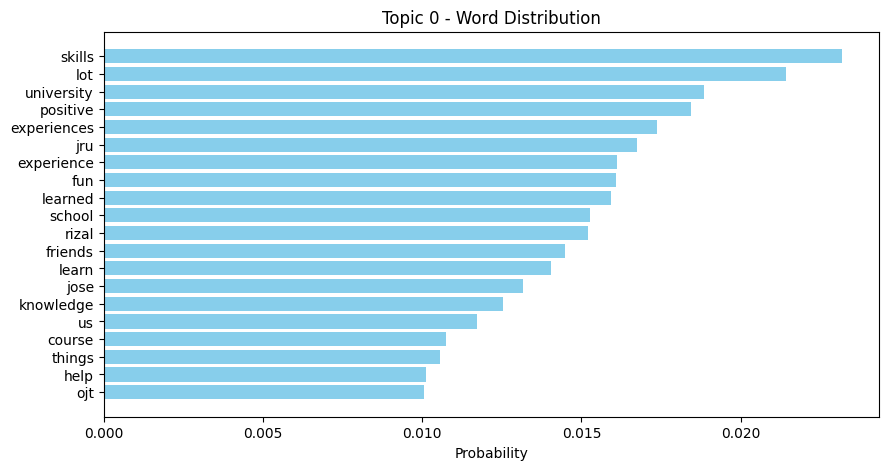

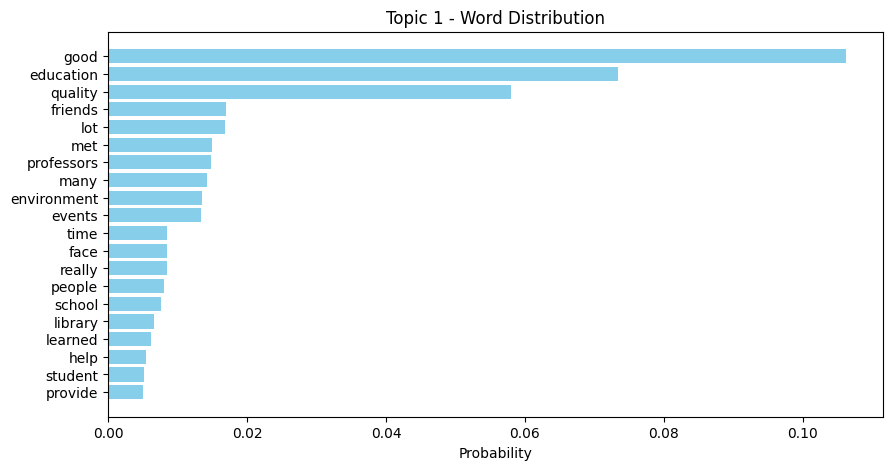

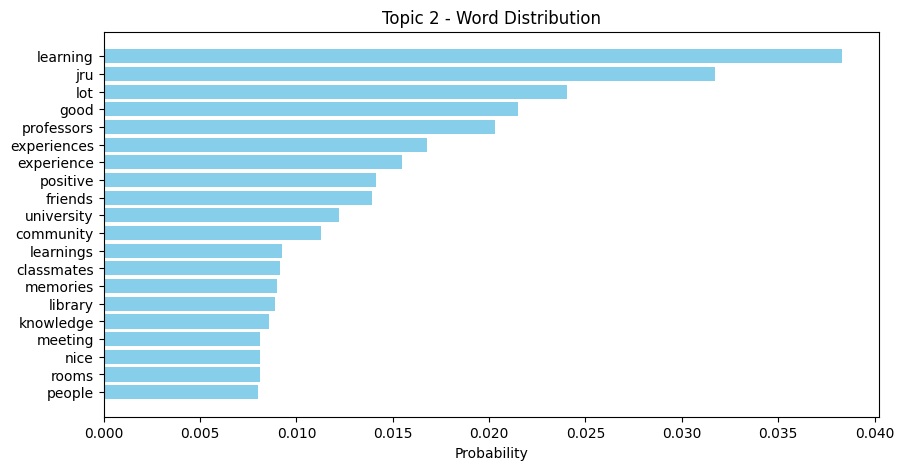

In [ ]:
import matplotlib.pyplot as plt

def plot_distribution(lda_model, num_topics=3):
    for i in range(num_topics):
        words = lda_model.show_topic(i, topn=20)

        word_freq = {word: prob for word, prob in words}

        words_sorted = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
        words, probs = zip(*words_sorted)

        plt.figure(figsize=(10, 5))
        plt.barh(words, probs, color='skyblue')
        plt.xlabel('Probability')
        plt.title(f"Topic {i} - Word Distribution")
        plt.gca().invert_yaxis()
        plt.show()

        print("\n\n")

plot_distribution(positive_bow_lda_model)

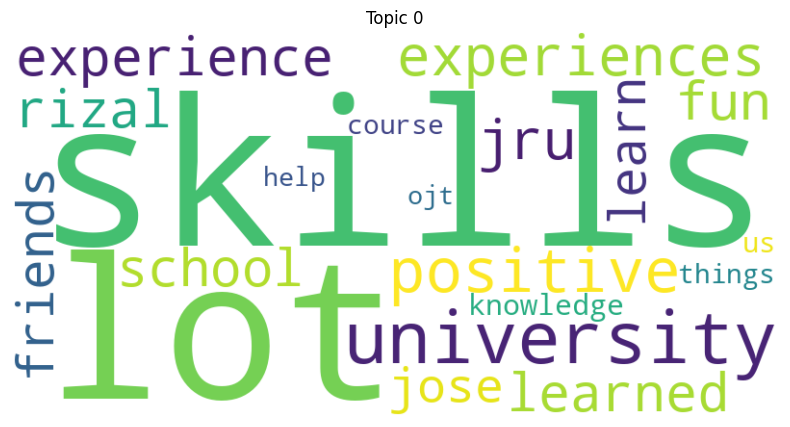

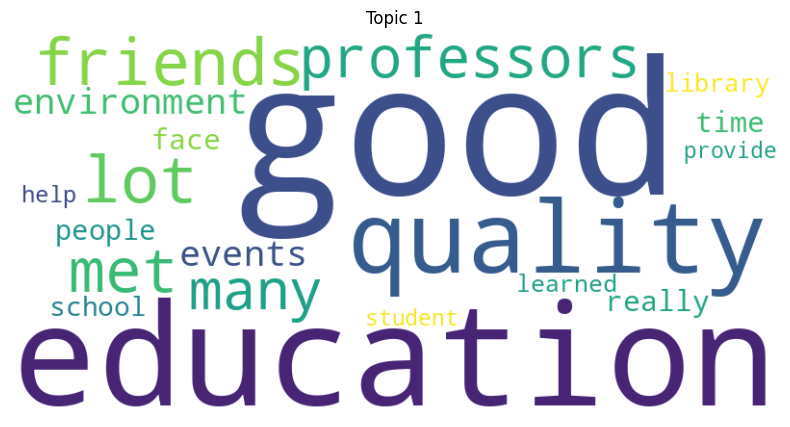

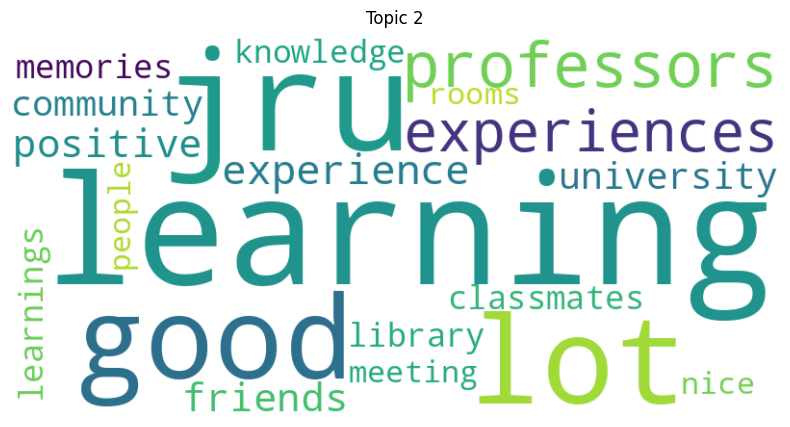

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def plot_word_cloud(lda_model, num_topics=3):
    for i in range(num_topics):
        words = lda_model.show_topic(i, topn=20)

        word_freq = {word: prob for word, prob in words}

        wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(f"Topic {i}")
        plt.axis("off")
        plt.show()
        print("\n\n")

plot_word_cloud(positive_bow_lda_model)

* Negative

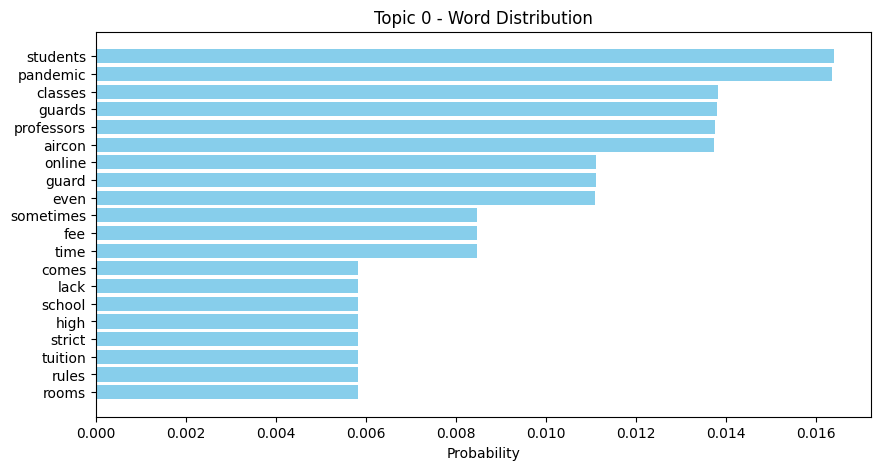

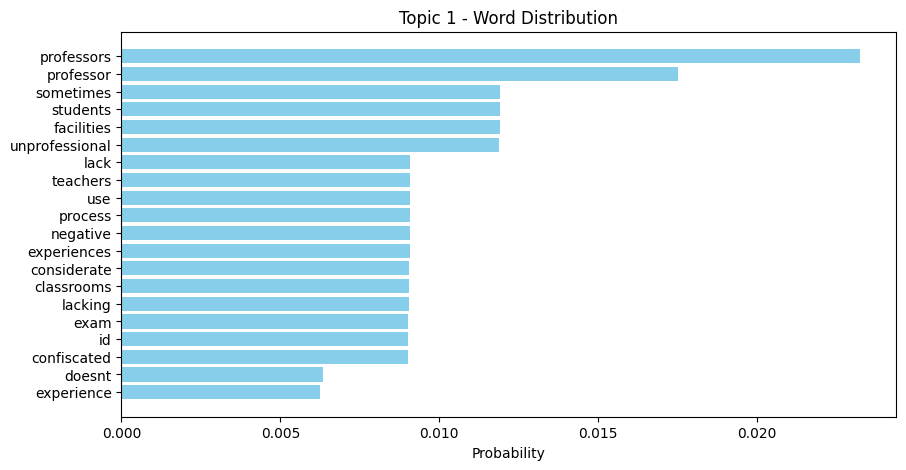

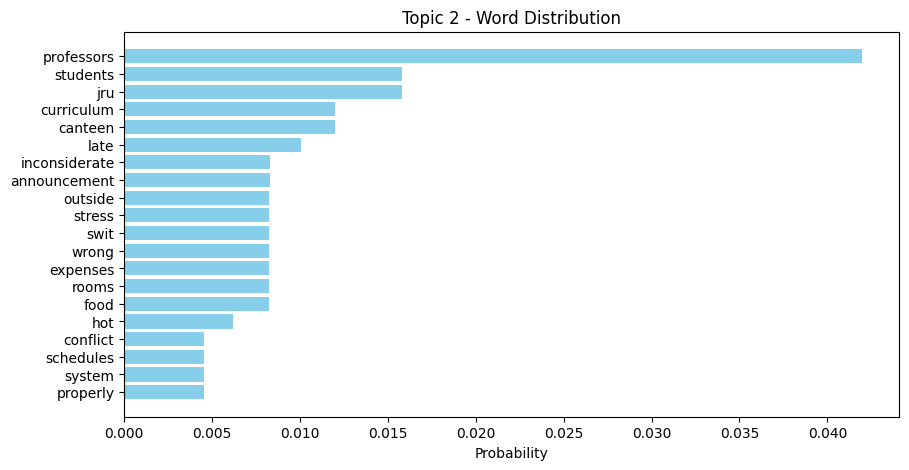

In [ ]:
import matplotlib.pyplot as plt

def plot_distribution(lda_model, num_topics=3):
    for i in range(num_topics):
        words = lda_model.show_topic(i, topn=20)

        word_freq = {word: prob for word, prob in words}

        words_sorted = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
        words, probs = zip(*words_sorted)

        plt.figure(figsize=(10, 5))
        plt.barh(words, probs, color='skyblue')
        plt.xlabel('Probability')
        plt.title(f"Topic {i} - Word Distribution")
        plt.gca().invert_yaxis()
        plt.show()

        print("\n\n")

plot_distribution(negative_bow_lda_model)

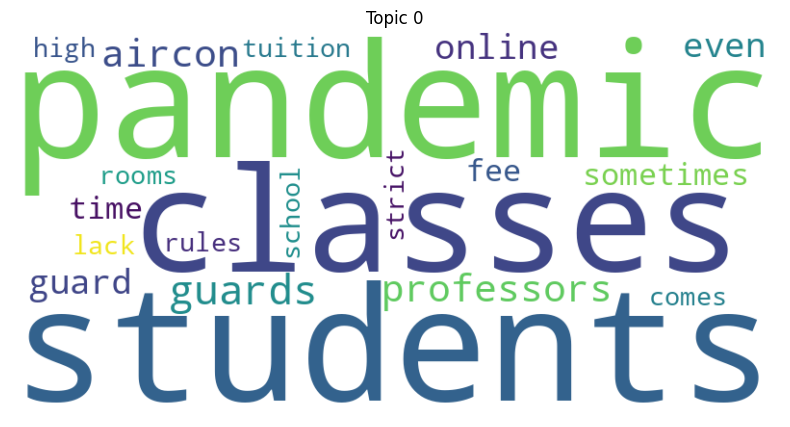

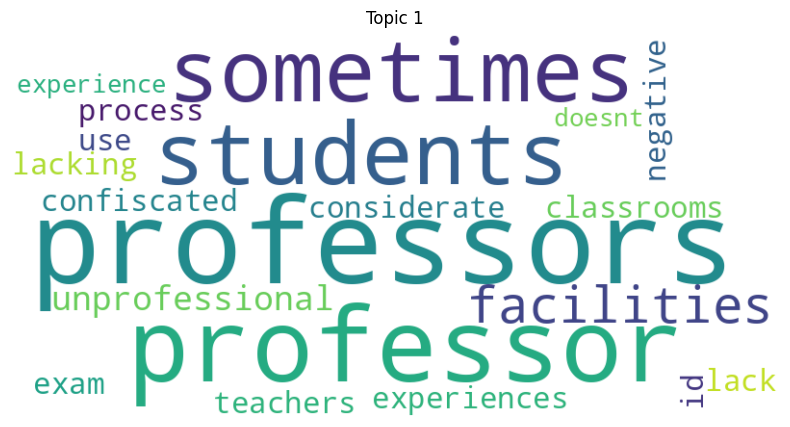

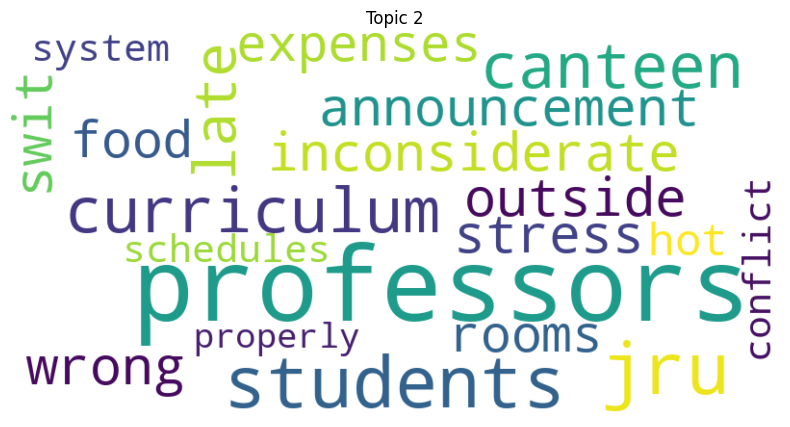

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def plot_word_cloud(lda_model, num_topics=3):
    for i in range(num_topics):
        words = lda_model.show_topic(i, topn=20)

        word_freq = {word: prob for word, prob in words}

        wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(f"Topic {i}")
        plt.axis("off")
        plt.show()
        print("\n\n")

plot_word_cloud(negative_bow_lda_model)

# LDA (TF-IDF)

In [ ]:
# TF-IDF (Positive)

from gensim import corpora
from gensim.models import TfidfModel, LdaModel, CoherenceModel
from pprint import pprint

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from pprint import pprint

positive_dataset.loc[:, 'tokenized_comment'] = positive_dataset.loc[:, 'comment'].apply(lambda x: x.split())

dictionary = corpora.Dictionary(positive_dataset["tokenized_comment"])

corpus = [dictionary.doc2bow(doc) for doc in positive_dataset["tokenized_comment"]]

tfidf_model = TfidfModel(corpus)

tfidf_corpus = tfidf_model[corpus]

for num_topics in range(2, 6):
    positive_tfidf_lda_model = LdaModel(corpus=tfidf_corpus, id2word=dictionary, num_topics=num_topics, passes=10, random_state=42)
    coherence_model = CoherenceModel(model=positive_tfidf_lda_model, corpus=tfidf_corpus, dictionary=dictionary, coherence='u_mass')
    print(f"Num Topics: {num_topics}, Coherence Score: {coherence_model.get_coherence()}")

    print(f"Topics for {num_topics} topics:")
    for idx, topic in positive_tfidf_lda_model.show_topics(num_topics=num_topics, num_words=5, formatted=False):
        topic_words = [word[0] for word in topic]
        print(f"  Topic {idx}: {', '.join(topic_words)}")
    print("\n")

Num Topics: 2, Coherence Score: -11.05167391302336
Topics for 2 topics:
  Topic 0: friends, experience, environment, fun, experiences
  Topic 1: good, education, quality, facilities, great


Num Topics: 3, Coherence Score: -13.173282974640799
Topics for 3 topics:
  Topic 0: environment, fun, friends, activities, everything
  Topic 1: good, education, quality, events, friends
  Topic 2: facilities, learning, great, good, experience


Num Topics: 4, Coherence Score: -12.950832112082583
Topics for 4 topics:
  Topic 0: fun, environment, everything, ojt, experiences
  Topic 1: good, education, quality, friends, events
  Topic 2: learning, lot, meeting, learnings, new
  Topic 3: facilities, great, good, experience, professors


Num Topics: 5, Coherence Score: -14.281125024845764
Topics for 5 topics:
  Topic 0: fun, ojt, friends, activities, lot
  Topic 1: good, education, quality, events, many
  Topic 2: learning, lot, learnings, good, positive
  Topic 3: facilities, good, internship, nice, 

In [ ]:
# TF-IDF (Negative)

from gensim import corpora
from gensim.models import TfidfModel, LdaModel, CoherenceModel
from pprint import pprint

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from pprint import pprint

negative_dataset.loc[:, 'tokenized_comment'] = negative_dataset.loc[:, 'comment'].apply(lambda x: x.split())

dictionary = corpora.Dictionary(negative_dataset["tokenized_comment"])

corpus = [dictionary.doc2bow(doc) for doc in negative_dataset["tokenized_comment"]]

tfidf_model = TfidfModel(corpus)

tfidf_corpus = tfidf_model[corpus]

for num_topics in range(2, 6):
    negative_tfidf_lda_model = LdaModel(corpus=tfidf_corpus, id2word=dictionary, num_topics=num_topics, passes=10, random_state=42)
    coherence_model = CoherenceModel(model=negative_tfidf_lda_model, corpus=tfidf_corpus, dictionary=dictionary, coherence='u_mass')
    print(f"Num Topics: {num_topics}, Coherence Score: {coherence_model.get_coherence()}")

    print(f"Topics for {num_topics} topics:")
    for idx, topic in negative_tfidf_lda_model.show_topics(num_topics=num_topics, num_words=5, formatted=False):
        topic_words = [word[0] for word in topic]
        print(f"  Topic {idx}: {', '.join(topic_words)}")
    print("\n")

Num Topics: 2, Coherence Score: -19.711278619560566
Topics for 2 topics:
  Topic 0: wifi, aircon, pandemic, guards, staff
  Topic 1: professors, internet, professor, slow, class


Num Topics: 3, Coherence Score: -19.322513603064245
Topics for 3 topics:
  Topic 0: aircon, pandemic, parking, guards, lack
  Topic 1: internet, process, grades, professor, considerate
  Topic 2: wifi, connection, professors, poor, late


Num Topics: 4, Coherence Score: -19.955524041591577
Topics for 4 topics:
  Topic 0: aircon, guard, lack, pandemic, parking
  Topic 1: professor, considerate, facilities, professors, teaching
  Topic 2: professors, internet, connection, late, canteen
  Topic 3: wifi, online, slow, connection, g


Num Topics: 5, Coherence Score: -20.361544634570873
Topics for 5 topics:
  Topic 0: aircon, pandemic, guard, guards, online
  Topic 1: considerate, teaching, internet, facilities, lack
  Topic 2: professors, encoding, wrong, expenses, curriculum
  Topic 3: staff, class, bad, online, 

# LDA Visualization (TF-IDF)



*   Positive


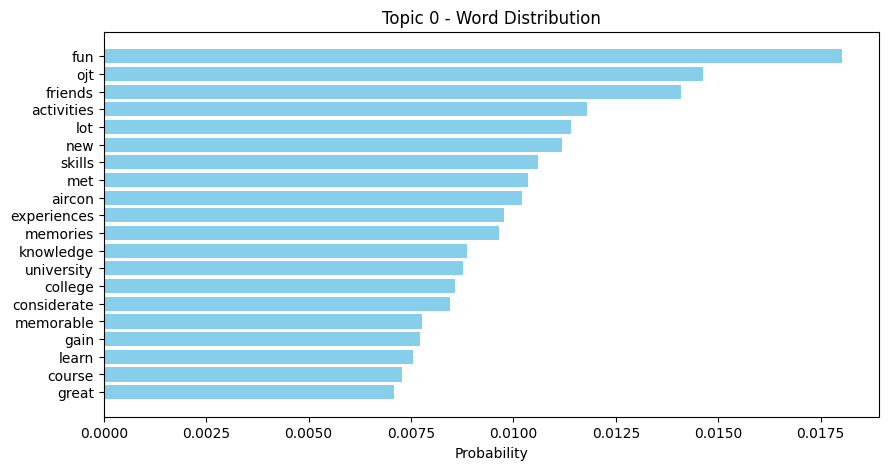

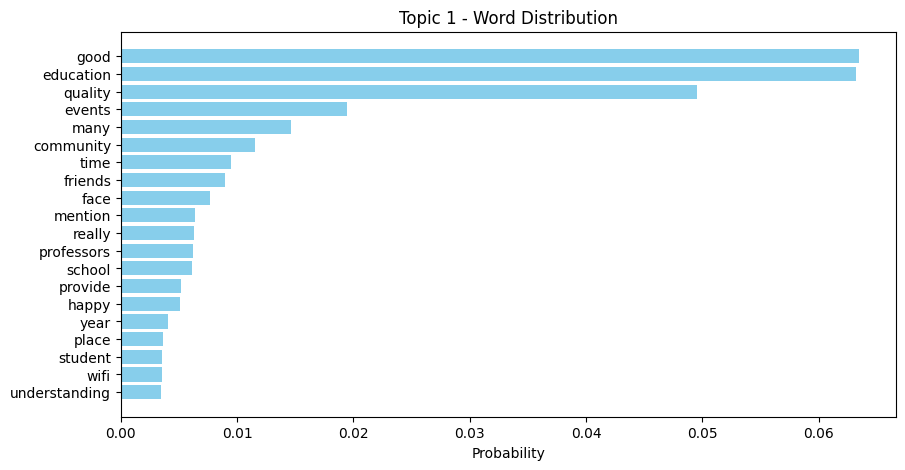

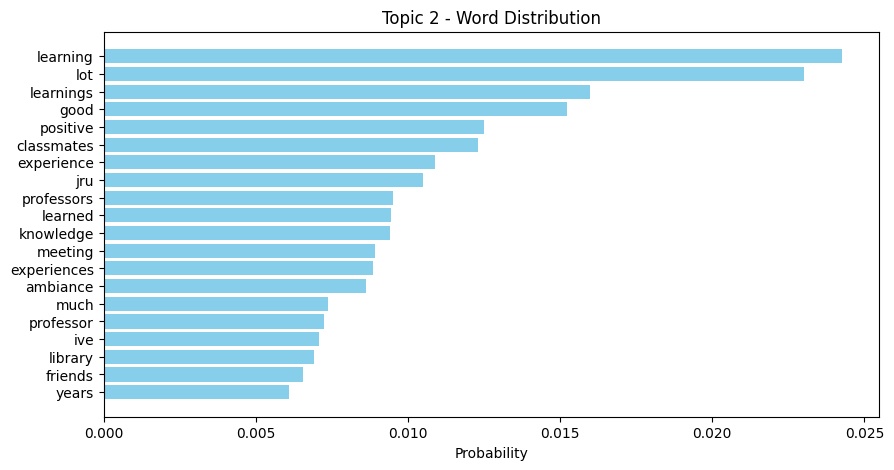

In [ ]:
import matplotlib.pyplot as plt

def plot_distribution(lda_model, num_topics=3):
    for i in range(num_topics):
        words = lda_model.show_topic(i, topn=20)

        word_freq = {word: prob for word, prob in words}

        words_sorted = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
        words, probs = zip(*words_sorted)

        plt.figure(figsize=(10, 5))
        plt.barh(words, probs, color='skyblue')
        plt.xlabel('Probability')
        plt.title(f"Topic {i} - Word Distribution")
        plt.gca().invert_yaxis()
        plt.show()

        print("\n\n")

plot_distribution(positive_tfidf_lda_model)

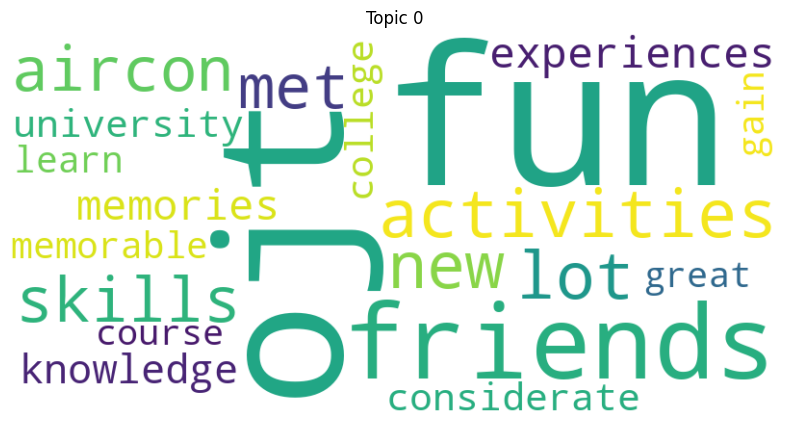

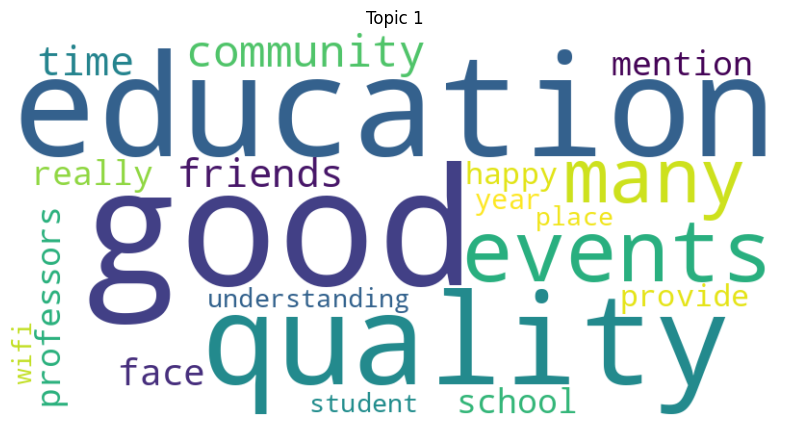

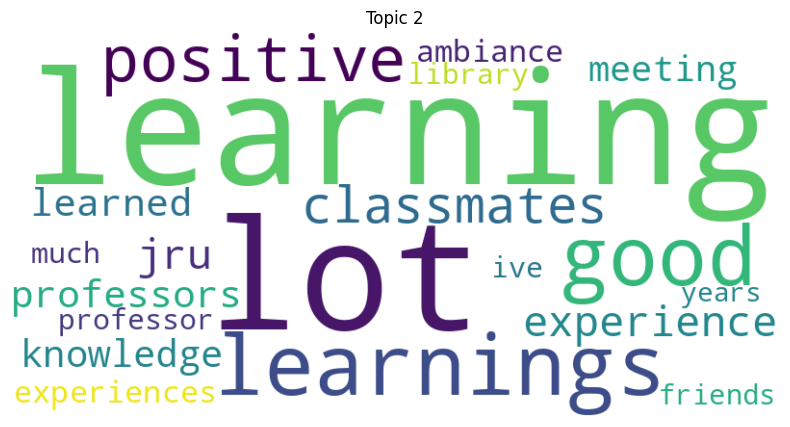

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def plot_word_cloud(lda_model, num_topics=3):
    for i in range(num_topics):
        words = lda_model.show_topic(i, topn=20)

        word_freq = {word: prob for word, prob in words}

        wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(f"Topic {i}")
        plt.axis("off")
        plt.show()
        print("\n\n")

plot_word_cloud(positive_tfidf_lda_model)



*   Negative



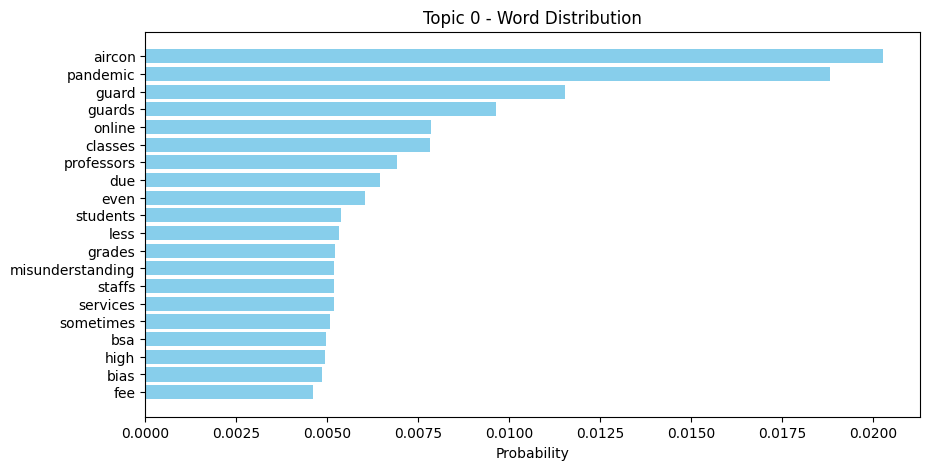

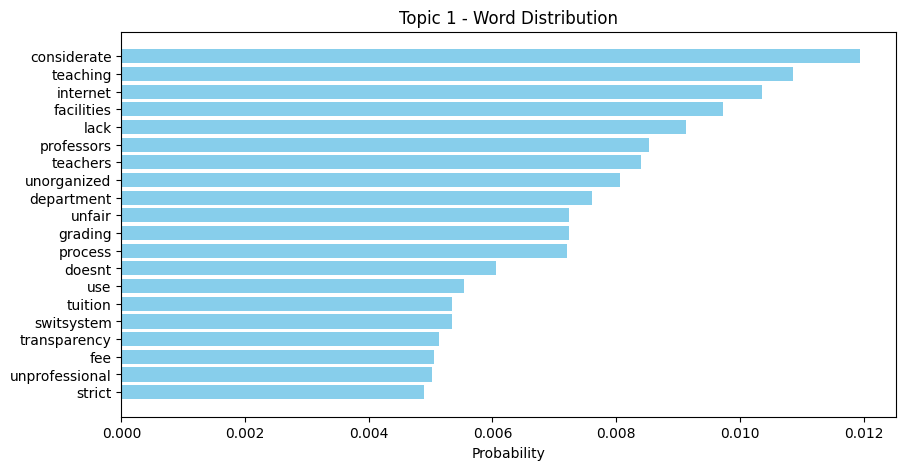

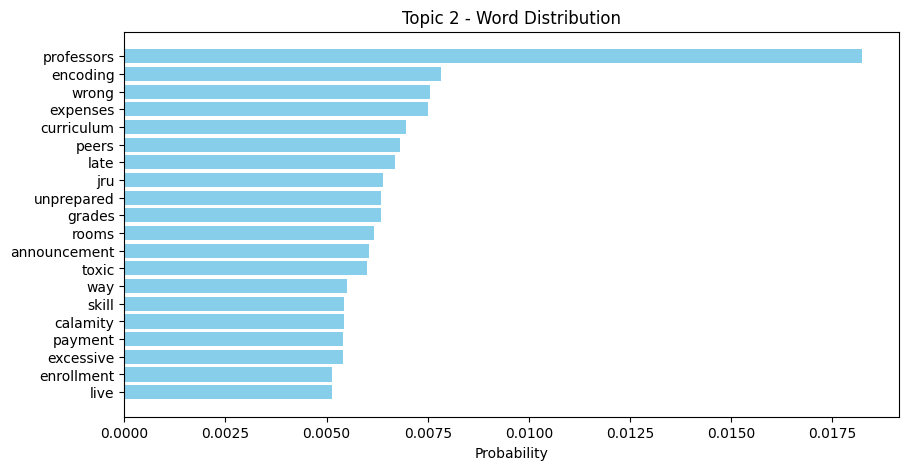

In [ ]:
import matplotlib.pyplot as plt

def plot_distribution(lda_model, num_topics=3):
    for i in range(num_topics):
        words = lda_model.show_topic(i, topn=20)

        word_freq = {word: prob for word, prob in words}

        words_sorted = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
        words, probs = zip(*words_sorted)

        plt.figure(figsize=(10, 5))
        plt.barh(words, probs, color='skyblue')
        plt.xlabel('Probability')
        plt.title(f"Topic {i} - Word Distribution")
        plt.gca().invert_yaxis()
        plt.show()

        print("\n\n")

plot_distribution(negative_tfidf_lda_model)

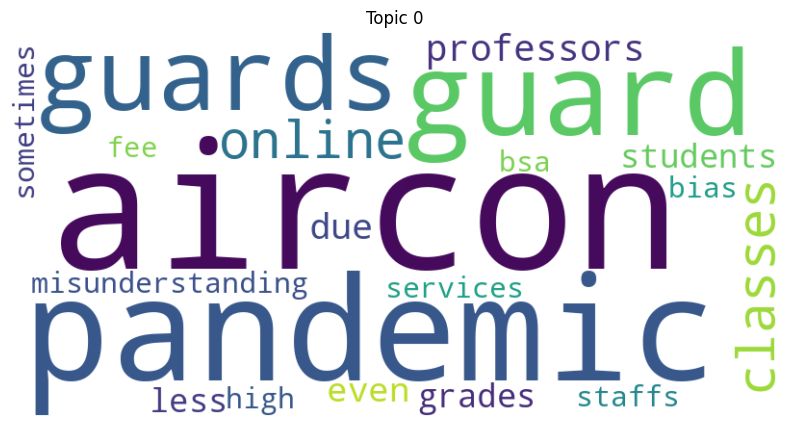

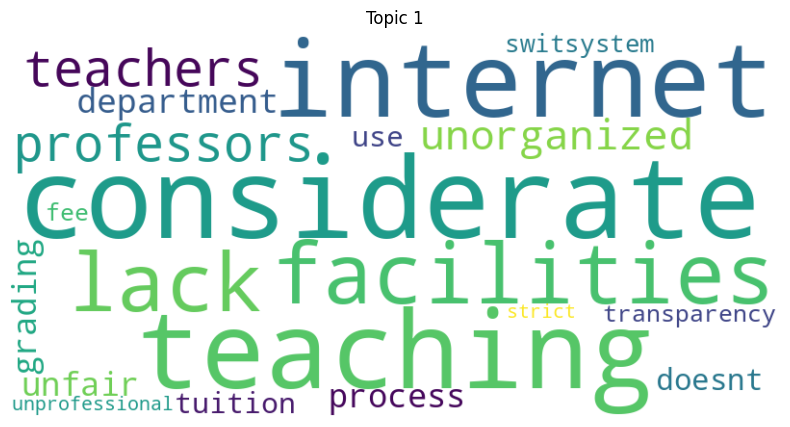

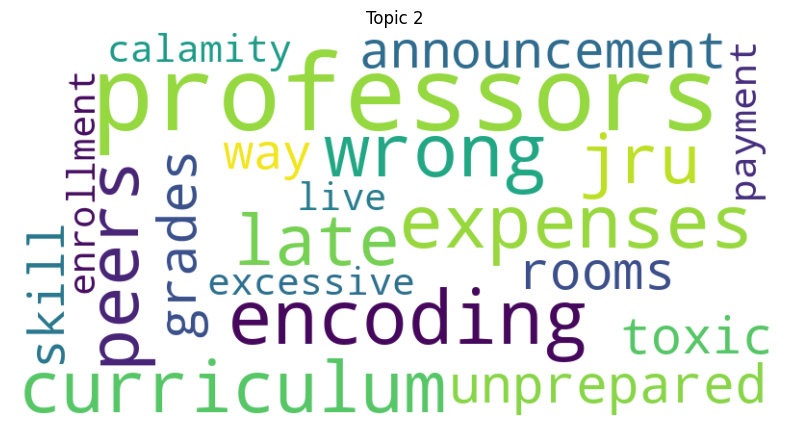

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def plot_word_cloud(lda_model, num_topics=3):
    for i in range(num_topics):
        words = lda_model.show_topic(i, topn=20)

        word_freq = {word: prob for word, prob in words}

        wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(f"Topic {i}")
        plt.axis("off")
        plt.show()
        print("\n\n")

plot_word_cloud(negative_tfidf_lda_model)